In [8]:
# Import Libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense

In [10]:
# Load Dataset
df = pd.read_csv("fifa_world_cup_2026_player_performance dataset.csv")

In [11]:
# Select Numerical Features
features = [
    'age',
    'minutes_played',
    'goals',
    'assists',
    'shots',
    'shots_on_target',
    'pass_accuracy',
    'tackles',
    'interceptions',
    'player_rating'
]

X = df[features]
y = df['performance_score']

In [13]:
# Scale Data
scaler = MinMaxScaler()
X_scaled = scaler.fit_transform(X)


In [18]:
# Train- test split
train_size = int(len(X) * 0.8)
X_train, X_test = X[:train_size], X[train_size:]
y_train, y_test = y[:train_size], y[train_size:]

In [19]:
# Build Deep Learning Model
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dense(32, activation='relu'))
model.add(Dense(16, activation='relu'))
model.add(Dense(1))

c:\Users\ABISHEK\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [20]:
# Compile Model
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)


In [21]:
# Train Model
history = model.fit(
    X_train,
    y_train,
    epochs=50,
    batch_size=32,
    validation_split=0.2,
    verbose=1
)


Epoch 1/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - loss: 122.7732 - mae: 5.9583 - val_loss: 12.3460 - val_mae: 2.5654
Epoch 2/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 7.8777 - mae: 2.1423 - val_loss: 6.9029 - val_mae: 1.9831
Epoch 3/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 7.2673 - mae: 2.0699 - val_loss: 7.2058 - val_mae: 2.0601
Epoch 4/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 7.0967 - mae: 2.0473 - val_loss: 6.5312 - val_mae: 1.9684
Epoch 5/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 7.0886 - mae: 2.0446 - val_loss: 6.8124 - val_mae: 1.9266
Epoch 6/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 7.0807 - mae: 2.0440 - val_loss: 6.5241 - val_mae: 1.9827
Epoch 7/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 6.9911 - mae: 2.0325 - val_loss: 7.3196 - val_mae: 1.9960
Epoch 8/50
1092/1092 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - loss: 6.9833 - mae: 2.0312 - val_loss: 6.7890 - val_mae: 1.9725
Epoch 9/50
1092/1092 ━━━━━━━━━━━━━━━━

In [22]:
# Evaluate
loss, mae = model.evaluate(X_test, y_test)
print("Test Loss :", loss)
print("Test MAE :", mae)

342/342 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 6.7488 - mae: 2.0071
Test Loss : 6.74876594543457
Test MAE : 2.007124662399292


In [23]:
# Prediction
predictions = model.predict(X_test)

342/342 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [24]:
result = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": predictions.flatten()
})

print(result.head())

   Actual  Predicted
0    58.2  60.274242
1    55.4  57.598152
2    66.3  66.705589
3    53.8  51.705528
4    59.1  62.373028


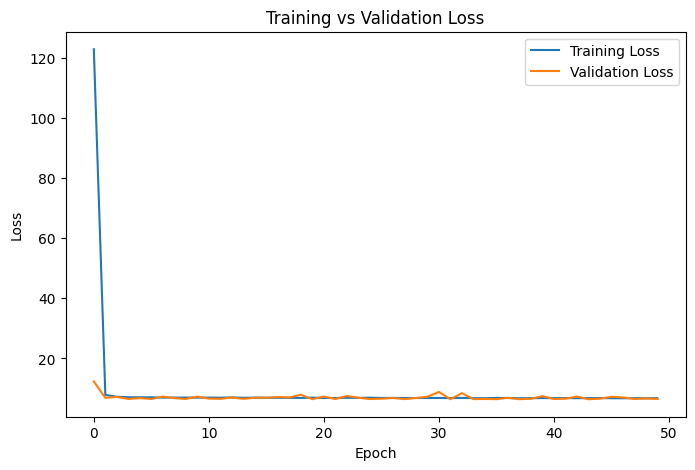

In [25]:
# Plot Loss
plt.figure(figsize=(8,5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training vs Validation Loss")
plt.legend()
plt.show()